# bin the spliced and unspliced counts

The splice counting was performed on 500k splits of the 2micron barcodes
1. read in loom, filter/rename features to match visium panel
2. Map barcodes to stardist labels
3. bin expression

In [1]:
import os

import scanpy as sc
import anndata as ad
import numpy as np
import scipy as sci
import pandas as pd
# import velocyto as vcy

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import bin2cell as b2c
# import loompy as lp
import xarray as xr
import h5py
import gc
import pickle as pk
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import dask

In [3]:
data_dir = "../01-SpaceRanger/"

In [4]:
data_path1 = "/mnt/isilon/cscb/Projects/10x_Visium/zhangj/SCTC-JZ-299/code/01-SpaceRanger/"
bin_path = "/outs/binned_outputs/square_002um"
spaceranger_image_path = "/outs/spatial"
img_base = "../../data/Images/HandE/"
spatial_cropped_key = 'spatial_cropped_150_buffer'
labels_key = "labels_he_expanded"

In [5]:
samp_data = pd.read_csv("../../documents/sample_meta.csv")

# test sample

## Prepare the segmentation results

Can either use insert_labels() from bin2cell or...
borrow that code

I would also need to run expand labels...

In [5]:
fname = samp_data.Name.iloc[0]
fname = samp_data.Name.unique()[0]
# fname = "FBC106_E8"
path = data_path1 + fname + bin_path
source_image_path = img_base + samp_data.HandE.loc[samp_data.Name == fname].values[0] + ".tif"
spaceranger_image_path = data_path1 + fname + "/outs/spatial"

In [7]:
adata = b2c.read_visium(path, 
                        source_image_path = source_image_path, 
                        spaceranger_image_path = spaceranger_image_path
                       )
adata.var_names_make_unique()

sc.pp.filter_genes(adata, min_cells=3)
sc.pp.filter_cells(adata, min_counts=1)

# process the image and segment
# mpp = 0.3
# b2c.scaled_he_image(adata, mpp=mpp, save_path="stardist/"+fname+"he.tiff")

# b2c.stardist(image_path="stardist/"+fname+"he.tiff", 
#          labels_npz_path="stardist/"+fname+".npz", 
#          stardist_model="2D_versatile_he", 
#          prob_thresh=0.01
#         )
crop_coords = b2c.get_crop(adata, basis="spatial", spatial_key="spatial", mpp=None, buffer=150)
adata.obsm[spatial_cropped_key] = adata.obsm["spatial"].copy()
adata.obsm[spatial_cropped_key][:,0] -= crop_coords[0]
adata.obsm[spatial_cropped_key][:,1] -= crop_coords[1]

print("inserting labels")
b2c.insert_labels(adata, 
              labels_npz_path="../03-segmentation/stardist/"+fname+".npz", 
              basis="spatial", 
              spatial_key="spatial_cropped_150_buffer",
              mpp=0.3, 
              labels_key="labels_he"
             )

b2c.expand_labels(adata, 
              labels_key='labels_he', 
              expanded_labels_key="labels_he_expanded"
             )
# drop background bins
adata = adata[adata.obs[labels_key]!=0]

/home/smithd30/miniconda3/envs/stardist/lib/python3.12/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/smithd30/miniconda3/envs/stardist/lib/python3.12/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


inserting labels


In [6]:
cell_adata = sc.read_h5ad("../03-segmentation/seg_dilate/"+fname+".h5ad")
sc.pp.calculate_qc_metrics(cell_adata, inplace=True)
cell_adata.obs.describe()

,object_id,bin_count,array_row,array_col,Absolute.X,Absolute.Y,cropped.X,cropped.Y,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
count,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000,664243.000000
mean,360954.212082,15.159232,1685.306754,1665.712367,26607.054373,17860.302608,6231.054373,6301.302608,87.771407,4.115344,96.884964,4.187464,74.144808,89.994530,98.067576,99.958686
std,203149.255505,9.121818,958.816531,967.163711,3445.845311,3478.006772,3445.845311,3478.006772,81.598326,0.897683,95.084412,0.925540,27.133448,18.166795,7.452208,0.897631
min,1.000000,1.000000,0.000000,0.000000,20528.452924,11709.881242,152.452924,150.881242,1.000000,0.693147,1.000000,0.693147,15.175097,23.914894,34.978723,55.562660
25%,188171.500000,9.000000,859.375000,824.394444,23630.616590,14852.442118,3254.616590,3293.442118,33.000000,3.526361,35.000000,3.583519,47.747748,87.200000,100.000000,100.000000
50%,361870.000000,13.000000,1684.538462,1670.848485,26607.173455,17840.642598,6231.173455,6281.642598,61.000000,4.127134,66.000000,4.204693,82.857143,100.000000,100.000000,100.000000
75%,535169.500000,20.000000,2514.166667,2503.218254,29576.753088,20884.462196,9200.753088,9325.462196,116.000000,4.762174,127.000000,4.852030,100.000000,100.000000,100.000000,100.000000
max,720876.000000,109.000000,3349.000000,3349.000000,32764.862387,23947.890923,12388.862387,12388.890923,1195.000000,7.086738,1569.000000,7.358831,100.000000,100.000000,100.000000,100.000000


In [25]:
g_thresh = np.array([cell_adata.obs.n_genes_by_counts.quantile(0.5), 50])
sc.pp.filter_cells(cell_adata, min_genes=g_thresh.min())

In [10]:
keep_cells = cell_adata.obs.object_id.values
adata = adata[adata.obs.labels_he_expanded.isin(keep_cells),:]
adata

View of AnnData object with n_obs × n_vars = 7704823 × 17891
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'labels_he', 'labels_he_expanded'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial', 'bin2cell'
    obsm: 'spatial', 'spatial_cropped_150_buffer'

In [11]:
adata.write("checkpoint.h5ad")

/home/smithd30/miniconda3/envs/stardist/lib/python3.12/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/home/smithd30/miniconda3/envs/stardist/lib/python3.12/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


In [7]:
adata = sc.read_h5ad("checkpoint.h5ad")

## format the splice counts

In [8]:

filename = fname+'/outs/binned_outputs/square_002um/raw_probe_bc_matrix.h5'
f = h5py.File(data_dir+filename, 'r')
# ds = xr.open_dataset(filename, engine="h5netcdf")


In [9]:
g = f["matrix"]  # adjust this path as needed
data = g["data"][:]
indices = g["indices"][:]
indptr = g["indptr"][:]
shape = g["shape"][:]

X = sci.sparse.csr_matrix((data, indices, indptr), shape=np.roll(shape,1))
# da_X = dask.array.from_array(X, chunks=(5e4,1e5))

In [10]:
bc_mask = [bc in adata.obs_names for bc in g['barcodes'][:].astype(str)]


In [11]:
X = X[bc_mask]
x_bc = g['barcodes'][:].astype(str)[bc_mask]
# da_X.shape

In [17]:
# da_X = da_X.compute()
# da_X

<Compressed Sparse Row sparse matrix of dtype 'int32'
	with 57088562 stored elements and shape (7704823, 54580)>

In [12]:
# loop the columns into a dataset 
feats = f['matrix']['features']
feat_keys = feats.keys()

df = pd.DataFrame()
for key in feat_keys:
    if isinstance(feats[key], h5py.Dataset):
        df[str(key)] = feats[key][...]
df.probe_region = df.probe_region.astype(str)
df.name = df.name.astype(str)
df.gene_id = df.gene_id.astype(str)
df.gene_name = df.gene_name.astype(str)
df.head()

,feature_type,filtered_probes,gene_id,gene_name,genome,id,name,probe_region
0,b'Gene Expression',False,DEPRECATED_ENSG00000001630,DEPRECATED_ENSG00000001630,b'GRCh38',b'DEPRECATED_ENSG00000001630|CYP51A1|5c60a99',CYP51A1|5c60a99,unspliced
1,b'Gene Expression',False,DEPRECATED_ENSG00000006047,DEPRECATED_ENSG00000006047,b'GRCh38',b'DEPRECATED_ENSG00000006047|YBX2|6bb010c',YBX2|6bb010c,unspliced
2,b'Gene Expression',False,DEPRECATED_ENSG00000006047,DEPRECATED_ENSG00000006047,b'GRCh38',b'DEPRECATED_ENSG00000006047|YBX2|db3fdd6',YBX2|db3fdd6,unspliced
3,b'Gene Expression',False,DEPRECATED_ENSG00000006534,DEPRECATED_ENSG00000006534,b'GRCh38',b'DEPRECATED_ENSG00000006534|ALDH3B1|c41b7d0',ALDH3B1|c41b7d0,unspliced
4,b'Gene Expression',False,DEPRECATED_ENSG00000006634,DEPRECATED_ENSG00000006634,b'GRCh38',b'DEPRECATED_ENSG00000006634|DBF4|8e5434c',DBF4|8e5434c,unspliced


In [13]:
X = X[:,~df.gene_id.str.contains("DEPRECATED").values]
df = df.loc[~df.gene_id.str.contains("DEPRECATED"),:]
df.shape

(54018, 8)

In [14]:
# matrix that has splices counts for gene A and unsplice counts for gene A
X_splice = X[:,(df.probe_region == "spliced").values]
X_unsplice = X[:,(df.probe_region == "unspliced").values]

df_splice = df.loc[(df.probe_region == "spliced").values,:]
df_unsplice = df.loc[(df.probe_region == "unspliced").values,:]

In [19]:
X_unsplice

<Compressed Sparse Row sparse matrix of dtype 'int32'
	with 49369899 stored elements and shape (7704823, 46469)>

In [32]:
# xr.DataArray(pd.get_dummies(df_unsplice.gene_id).to_numpy(), dims=['probe','gene'])

<xarray.DataArray (probe: 46469, gene: 18250)> Size: 848MB
array([[ True, False, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       ...,
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False, False,  True]])
Dimensions without coordinates: probe, gene

In [29]:
# X_unsplice = xr.DataArray(X_unsplice,
#                          dims=['barcode','probe'],
#                          coords={'barcode': g['barcodes'][:].astype(str)[bc_mask], 'probe':df_unsplice.index.values})

In [15]:
genes_splice = sci.sparse.csr_matrix(pd.get_dummies(df_splice.gene_id, sparse=True))
x_splice_agg = X_splice.dot(genes_splice)
df_splice_agg = df_splice.loc[~df_splice.gene_id.duplicated(),:]

In [16]:
genes_unsplice = sci.sparse.csr_matrix(pd.get_dummies(df_unsplice.gene_id, sparse=True))
# genes_unsplice = xr.DataArray(pd.get_dummies(df_unsplice.gene_id).to_numpy(), dims=['probe','gene']).chunk(chunks="auto")
x_unsplice_agg = X_unsplice.dot(genes_unsplice)
df_unsplice_agg = df_unsplice.loc[~df_unsplice.gene_id.duplicated(),:]

In [57]:
# geneu = df_unsplice_agg['gene_name'] + "." + df_unsplice_agg.groupby('gene_name').cumcount().astype(str)
# df_unsplice_agg['gene_name'] = geneu.replace(r'\.0$', '', regex=True)
geneu = df_splice_agg['gene_name'] + "." + df_splice_agg.groupby('gene_name').cumcount().astype(str)
df_splice_agg['gene_name'] = geneu.replace(r'\.0$', '', regex=True)

/tmp/ipykernel_3853894/955443838.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_splice_agg['gene_name'] = geneu.replace(r'\.0$', '', regex=True)


In [24]:
type(x_unsplice_agg)

scipy.sparse._csr.csr_matrix

In [ ]:
test = x_unsplice_agg.compute()
test

In [19]:
# x_unsplice_agg = sci.sparse.csr_matrix(x_unsplice_agg)

In [20]:
# import sys
# print(sys.getsizeof(x_unsplice_agg))
# print(sys.getsizeof(x_splice_agg))

48
176114019664


## Aggregating the cell splice/unsplice counts

many more barcodes in raw probe counts than processed adata. Need to filter

should I filter than sort? yes, more efficient. filtering is a O(n) task. sorting is a O(k log k) task

should I take all genes? yes, missing genes in splice or unsplice will just be 0


In [48]:
x_unsplice_agg

<Compressed Sparse Row sparse matrix of dtype 'int32'
	with 49265943 stored elements and shape (7704823, 18250)>

In [31]:
da_unsplice.shape

(7704823, 18250)

In [32]:
da_X = dask.array.from_array(x_unsplice_agg)
da_unsplice = xr.DataArray(
    da_X,
    dims=['barcode','gene'],
    coords={'barcode': x_bc, 'gene':df_unsplice_agg.gene_name.values}
)

In [49]:
len(adata.obs_names)

7704823

In [33]:
# this is very slow...
# da_unsplice = da_unsplice.loc[adata.obs_names,:]
da_unsplice = da_unsplice.sel(barcode=adata.obs_names)

In [34]:
da_unsplice

<xarray.DataArray 'array-e4bcdb5cf1d5cb7eb295264a2c9420c5' (barcode: 7704823,
                                                            gene: 18250)> Size: 562GB
dask.array<getitem, shape=(7704823, 18250), dtype=int32, chunksize=(6783, 5792), chunktype=scipy.csr_matrix>
Coordinates:
  * barcode  (barcode) <U45 1GB 's_002um_00658_01498-1' ... 's_002um_03170_00...
  * gene     (gene) object 146kB 'TSPAN6' 'TNMD' ... 'NOTCH2NLC' 'AC007244.1'

In [29]:
test = da_unsplice.compute()
test

ValueError: replacement data must match the Variable's shape. replacement data has shape (); Variable has shape (7704823, 18250)

In [33]:
da_splice = xr.DataArray(
    x_splice_agg,
    dims=['barcode','gene'],
    coords={'barcode': g['barcodes'][:].astype(str)[bc_mask], 'gene':df_splice_agg.gene_name.values}
)

In [34]:
da_splice = da_splice.loc[adata.obs_names,:]

In [ ]:
da_unsplice = da_unsplice.compute()
da_unsplice

In [43]:
cell_to_bin = pd.get_dummies(adata.obs[labels_key], sparse=True)
cell_names = [str(i) for i in cell_to_bin.columns]
cell_to_bin = cell_to_bin.sparse.to_coo().tocsr().T

# cell_to_bin = pd.get_dummies(adata.obs[labels_key]).to_numpy().T
# cell_names = [str(i) for i in cell_to_bin.columns]

# cell_to_bin = xr.DataArray(dask.array.from_array(cell_to_bin), dims=("cell","barcode"))

In [18]:
print(adata.shape)
print(len(x_bc))

(7704823, 17891)
7704823


In [19]:
# instead of reorganizing splice matrix, organize the dummy variables
labs = adata.obs[labels_key].loc[x_bc]
cell_to_bin = pd.get_dummies(labs, sparse=True)
cell_names = [str(i) for i in cell_to_bin.columns]
cell_to_bin = cell_to_bin.sparse.to_coo().tocsr().T

In [34]:
adata.obs[labels_key].unique()[0:20]

array([398406, 139200, 679090, 590967, 633363, 462851, 551406, 181005,
       138359, 464173, 108795, 356862, 183427,  38324, 666492, 364196,
       167741,   3477, 246607, 440225])

In [36]:
del X, df, X_splice, X_unsplice
gc.collect()

2728480

In [55]:
# cell_unsplice_X = cell_to_bin.dot(x_unsplice_agg) # or whatever the splice/unspliced count matrix is
cell_splice_X = cell_to_bin.dot(x_splice_agg) # or whatever the splice/unspliced count matrix is

In [56]:
cell_splice_X.shape

(392988, 6188)

In [41]:
# the xarray dot product is taking forever to compute...
# try csr product (compute da_unsplice beforehand)...
test = cell_unsplice_X.compute()
test

KeyboardInterrupt: 

## Final processing and organization


In [38]:
# cell_adata = sc.read_h5ad("../03-segmentation/seg_dilate/FBC106_E8.h5ad")
# cell_adata = adata_proc

In [37]:
out = cell_unsplice_X.compute()
out

ValueError: replacement data must match the Variable's shape. replacement data has shape (); Variable has shape (392988, 18250)

In [53]:
cell_adata

AnnData object with n_obs × n_vars = 392988 × 17891
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'Absolute.X', 'Absolute.Y', 'cropped.X', 'cropped.Y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'

In [41]:
cell_adata.obs['unspliced_count'] = cell_unsplice_X.sum(axis=1)
cell_adata.obs['spliced_count'] = cell_splice_X.sum(axis=1)


In [79]:
cell_adata.obs['splice_ratio'] = cell_adata.obs['unspliced_count'] / cell_adata.obs['spliced_count']
cell_adata.obs.loc[cell_adata.obs['splice_ratio']==np.inf, 'splice_ratio'] = -1*cell_adata.obs.loc[cell_adata.obs['splice_ratio']==np.inf, 'unspliced_count'].values

In [99]:
cell_adata.obs.head(20)

,object_id,bin_count,array_row,array_col,Absolute.X,Absolute.Y,cropped.X,cropped.Y,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,n_genes,unspliced_count,spliced_count,splice_ratio
11,11,8,3218.375000,3275.125000,14700.805497,16423.352108,642.805497,417.352108,10,2.397895,12.0,2.564949,100.0,100.0,100.0,100.0,10,11,1,11.000000
12,12,6,3011.500000,3204.166667,15443.937198,16679.826336,1385.937198,673.826336,10,2.397895,10.0,2.397895,100.0,100.0,100.0,100.0,10,6,4,1.500000
17,17,12,3074.416667,2845.833333,15215.319679,17967.450937,1157.319679,1961.450937,11,2.484907,16.0,2.833213,100.0,100.0,100.0,100.0,11,15,1,15.000000
28,28,14,3050.428571,2889.071429,15301.842859,17812.192047,1243.842859,1806.192047,17,2.890372,20.0,3.044523,100.0,100.0,100.0,100.0,17,18,2,9.000000
37,37,12,2829.750000,2920.750000,16095.299064,17699.826253,2037.299064,1693.826253,36,3.610918,40.0,3.713572,100.0,100.0,100.0,100.0,36,34,6,5.666667
41,41,7,3002.428571,3280.571429,15477.069490,16405.246581,1419.069490,399.246581,12,2.564949,12.0,2.564949,100.0,100.0,100.0,100.0,12,9,3,3.000000
43,43,22,2911.954545,2920.818182,15799.811627,17699.020498,1741.811627,1693.020498,31,3.465736,35.0,3.583519,100.0,100.0,100.0,100.0,31,29,6,4.833333
49,49,12,3164.000000,3057.416667,14894.762417,17206.288871,836.762417,1200.288871,18,2.944439,21.0,3.091043,100.0,100.0,100.0,100.0,18,18,3,6.000000
52,52,15,2891.200000,2827.533333,15873.774295,18034.481459,1815.774295,2028.481459,38,3.663562,46.0,3.850148,100.0,100.0,100.0,100.0,38,41,5,8.200000
53,53,11,2996.090909,3202.909091,15499.317105,16684.451819,1441.317105,678.451819,14,2.708050,19.0,2.995732,100.0,100.0,100.0,100.0,14,17,2,8.500000


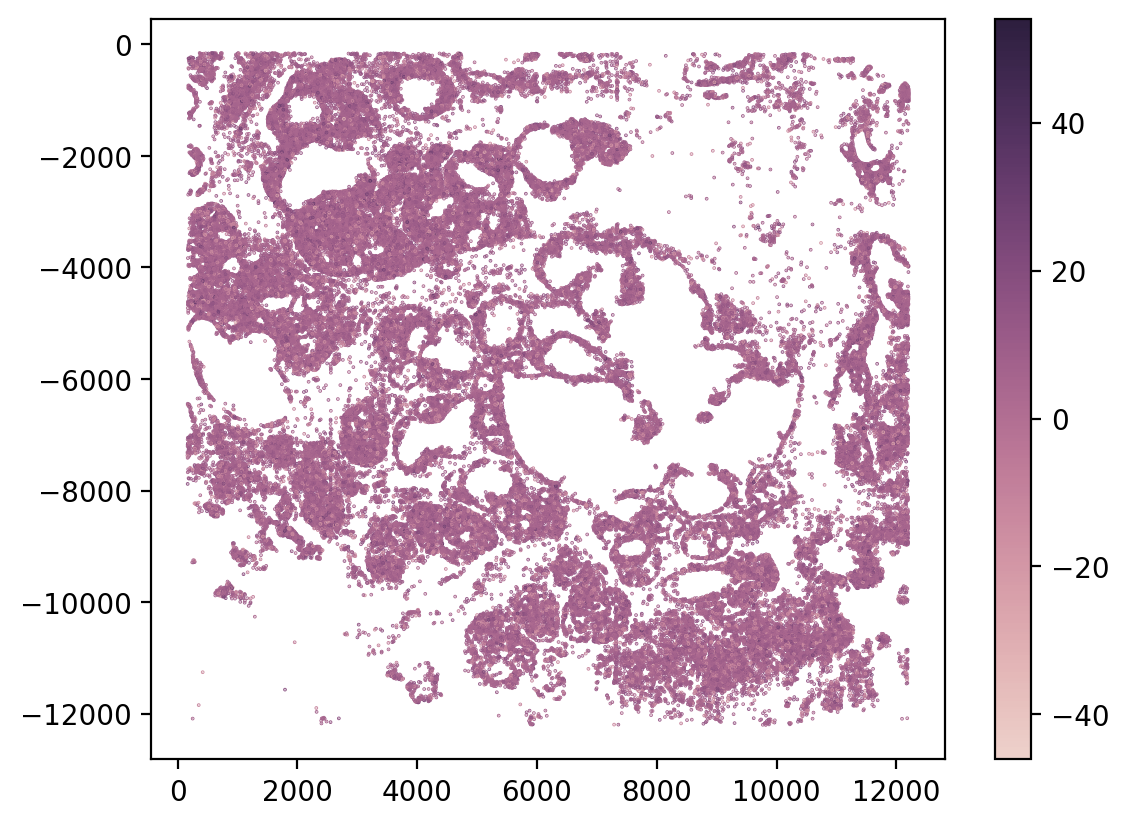

In [80]:
cmap = sns.cubehelix_palette(as_cmap=True)

f, ax = plt.subplots()
points = ax.scatter(cell_adata.obs['cropped.X'].values, 
                    cell_adata.obs['cropped.Y'].values*-1, 
                    c=cell_adata.obs['splice_ratio'].values, 
                    s=0.1, 
                    cmap=cmap)
f.colorbar(points)

In [69]:
print(len(set(cell_adata.var_names)) == len(cell_adata.var_names))
print(len(set(df_unsplice_agg.gene_name.values)) == len(df_unsplice_agg.gene_name.values))

True
True


In [44]:
print(len(set(df_unsplice_agg.gene_name.values)))
print(len(df_unsplice_agg.gene_name.values))

18247
18250


In [68]:
s = df_unsplice_agg['gene_name'] + "." + df_unsplice_agg.groupby('gene_name').cumcount().astype(str)
df_unsplice_agg['gene_name'] = s.replace(r'\.0$', '', regex=True)
s = df_splice_agg['gene_name'] + "." + df_splice_agg.groupby('gene_name').cumcount().astype(str)
df_splice_agg['gene_name'] = s.replace(r'\.0$', '', regex=True)

/tmp/ipykernel_2202551/3438980847.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unsplice_agg['gene_name'] = s.replace(r'\.0$', '', regex=True)
/tmp/ipykernel_2202551/3438980847.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_splice_agg['gene_name'] = s.replace(r'\.0$', '', regex=True)


In [62]:
print(len(cell_names) == len(cell_adata.obs.object_id.values))
set(cell_adata.obs.object_id.astype(str).values) - set(cell_names)

True


set()

In [63]:
# organize unspliced 
da_unsplice = xr.DataArray(
    cell_unsplice_X.toarray(),
    dims=['cell','gene'],
    coords={'cell': cell_names, 'gene': df_unsplice_agg.gene_name.values}
)

missing_genes = list(set(cell_adata.var_names) - set(da_unsplice.coords['gene'].values))

# # damn these steps are also slow...any sorting I guess
if len(missing_genes) > 0:
    da_empty = xr.DataArray(
        np.zeros((da_unsplice.shape[0], len(missing_genes))),
        dims=['cell','gene'],
        coords={"cell": cell_names, "gene": missing_genes}
    )
    da_unsplice_full = xr.concat([da_unsplice, da_empty], dim="gene")

da_unsplice = da_unsplice_full.loc[cell_adata.obs.object_id.astype(str).values,cell_adata.var_names.values]


In [64]:
# organize spliced 
da_splice = xr.DataArray(
    cell_splice_X.toarray(),
    dims=['cell','gene'],
    coords={'cell': cell_names, 'gene': df_splice_agg.gene_name.values}
)

missing_genes = list(set(cell_adata.var_names) - set(da_splice.coords['gene'].values))

# # damn these steps are also slow...any sorting I guess
if len(missing_genes) > 0:
    da_empty = xr.DataArray(
        np.zeros((da_splice.shape[0], len(missing_genes))),
        dims=['cell','gene'],
        coords={"cell": cell_names, "gene": missing_genes}
    )
    da_splice_full = xr.concat([da_splice, da_empty], dim="gene")

da_splice = da_splice_full.loc[cell_adata.obs.object_id.astype(str).values,cell_adata.var_names.values]


In [ ]:
cell_adata.uns['splice_counts'].sum(axis=1).shape

In [84]:
type(cell_adata.X)

scipy.sparse._csr.csr_matrix

In [91]:
da_splice.dims

('cell', 'gene')

In [ ]:
cell_adata.uns['splice_counts'] = {
    'data': sci.sparse.csr_matrix(da_splice.values),
    'coords': {k: v.values for k, v in da_splice.coords.items()}
}
cell_adata.uns['unsplice_counts'] = {
    'data': sci.sparse.csr_matrix(da_unsplice.values),
    'coords': {k: v.values for k, v in da_unsplice.coords.items()}
}

In [93]:
cell_adata.write("data/"+fname+".h5ad")

In [98]:
del x_unsplice_agg, x_splice_agg, da_unsplice, da_splice, da_splice_full, da_unsplice_full, cell_splice_X, cell_unsplice_X
gc.collect()

517

In [95]:
# format expression arrays to have all genes and in same order as processed cell adata
fname

'FBC106_E8'

In [11]:
for s in tqdm.tqdm(samp_data.Name.unique()):
    if s == "MBC14_A9": # this was trial sample
        continue
    # organize adata
    print('organizing adata')
    fname = s
    path = data_path1 + fname + bin_path
    source_image_path = img_base + samp_data.HandE.loc[samp_data.Name == fname].values[0] + ".tif"
    spaceranger_image_path = data_path1 + fname + "/outs/spatial"
    adata = b2c.read_visium(path, 
                        source_image_path = source_image_path, 
                        spaceranger_image_path = spaceranger_image_path
                       )
    adata.var_names_make_unique()

    sc.pp.filter_genes(adata, min_cells=3)
    sc.pp.filter_cells(adata, min_counts=1)
    crop_coords = b2c.get_crop(adata, basis="spatial", spatial_key="spatial", mpp=None, buffer=150)
    adata.obsm[spatial_cropped_key] = adata.obsm["spatial"].copy()
    adata.obsm[spatial_cropped_key][:,0] -= crop_coords[0]
    adata.obsm[spatial_cropped_key][:,1] -= crop_coords[1]

    b2c.insert_labels(adata, 
                  labels_npz_path="../03-segmentation/stardist/"+fname+".npz", 
                  basis="spatial", 
                  spatial_key="spatial_cropped_150_buffer",
                  mpp=0.3, 
                  labels_key="labels_he"
                 )

    b2c.expand_labels(adata, 
                  labels_key='labels_he', 
                  expanded_labels_key="labels_he_expanded"
                 )
    adata = adata[adata.obs[labels_key]!=0]
    cell_adata = sc.read_h5ad("../03-segmentation/seg_dilate/"+fname+".h5ad")
    sc.pp.calculate_qc_metrics(cell_adata, inplace=True)
    g_thresh = np.array([cell_adata.obs.n_genes_by_counts.quantile(0.5), 35])
    sc.pp.filter_cells(cell_adata, min_genes=g_thresh.min())
    keep_cells = cell_adata.obs.object_id.values
    adata = adata[adata.obs.labels_he_expanded.isin(keep_cells),:]
    
    #############~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    # spliced 
    print('processing spliced')
    # preparing splice counts
    print('preparing splice counts')
    filename = fname+'/outs/binned_outputs/square_002um/raw_probe_bc_matrix.h5'
    f = h5py.File(data_dir+filename, 'r')
    g = f["matrix"]  # adjust this path as needed
    data = g["data"][:]
    indices = g["indices"][:]
    indptr = g["indptr"][:]
    shape = g["shape"][:]
    X = sci.sparse.csr_matrix((data, indices, indptr), shape=np.roll(shape,1))
    bc_mask = [bc in adata.obs_names for bc in g['barcodes'][:].astype(str)]
    X = X[bc_mask]
    x_bc = g['barcodes'][:].astype(str)[bc_mask]
    feats = f['matrix']['features']

    df = pd.DataFrame()
    for key in feats.keys():
        if isinstance(feats[key], h5py.Dataset):
            df[str(key)] = feats[key][...]
    df.probe_region = df.probe_region.astype(str)
    df.name = df.name.astype(str)
    df.gene_id = df.gene_id.astype(str)
    df.gene_name = df.gene_name.astype(str)
    X = X[:,~df.gene_id.str.contains("DEPRECATED").values]
    df = df.loc[~df.gene_id.str.contains("DEPRECATED"),:]
    X_splice = X[:,(df.probe_region == "spliced").values]
    df_splice = df.loc[(df.probe_region == "spliced").values,:]
    genes_splice = sci.sparse.csr_matrix(pd.get_dummies(df_splice.gene_id, sparse=True))
    X_splice = X_splice.dot(genes_splice)
    df_splice_agg = df_splice.loc[~df_splice.gene_id.duplicated(),:]
    
    # first aggregation
    print("first aggregation")
    labs = adata.obs[labels_key].loc[x_bc]
    cell_to_bin = pd.get_dummies(labs, sparse=True)
    cell_names = [str(i) for i in cell_to_bin.columns]
    cell_to_bin = cell_to_bin.sparse.to_coo().tocsr().T
    cell_splice_X = cell_to_bin.dot(X_splice) # or whatever the splice/unspliced count matrix is
    # second aggregation
    print("second aggregation")
    geneu = df_splice_agg['gene_name'] + "." + df_splice_agg.groupby('gene_name').cumcount().astype(str)
    df_splice_agg['gene_name'] = geneu.replace(r'\.0$', '', regex=True)
    
    da_splice = xr.DataArray(
        cell_splice_X.toarray(),
        dims=['cell','gene'],
        coords={'cell': cell_names, 'gene': df_splice_agg.gene_name.values}
    )
    missing_genes = list(set(cell_adata.var_names) - set(da_splice.coords['gene'].values))
    if len(missing_genes) > 0:
        da_empty = xr.DataArray(
            np.zeros((da_splice.shape[0], len(missing_genes))),
            dims=['cell','gene'],
            coords={"cell": cell_names, "gene": missing_genes}
        )
        da_splice_full = xr.concat([da_splice, da_empty], dim="gene")
    da_splice = da_splice_full.loc[cell_adata.obs.object_id.astype(str).values, cell_adata.var_names.values]
    cell_adata.uns['splice_counts'] = {
        'data': sci.sparse.csr_matrix(da_splice.values),
        'coords': {k: v.values for k, v in da_splice.coords.items()}
    }
    cell_adata.obs['spliced_count'] = cell_adata.uns['splice_counts']['data'].sum(axis=1)
    del da_splice, da_splice_full, cell_splice_X, X_splice
    gc.collect()
    
    #############~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    # unspliced
    print('processing unspliced')
    X_unsplice = X[:,(df.probe_region == "unspliced").values]
    del X
    gc.collect()
    df_unsplice = df.loc[(df.probe_region == "unspliced").values,:]
    genes_unsplice = sci.sparse.csr_matrix(pd.get_dummies(df_unsplice.gene_id, sparse=True))
    X_unsplice = X_unsplice.dot(genes_unsplice)
    df_unsplice_agg = df_unsplice.loc[~df_unsplice.gene_id.duplicated(),:]
    
    print("first aggregation")
    cell_unsplice_X = cell_to_bin.dot(X_unsplice)
    
    geneu = df_unsplice_agg['gene_name'] + "." + df_unsplice_agg.groupby('gene_name').cumcount().astype(str)
    df_unsplice_agg['gene_name'] = geneu.replace(r'\.0$', '', regex=True)
    print("second aggregation")
    da_unsplice = xr.DataArray(
        cell_unsplice_X.toarray(),
        dims=['cell','gene'],
        coords={'cell': cell_names, 'gene': df_unsplice_agg.gene_name.values}
    )
    missing_genes = list(set(cell_adata.var_names) - set(da_unsplice.coords['gene'].values))
    if len(missing_genes) > 0:
        da_empty = xr.DataArray(
            np.zeros((da_unsplice.shape[0], len(missing_genes))),
            dims=['cell','gene'],
            coords={"cell": cell_names, "gene": missing_genes}
        )
        da_unsplice_full = xr.concat([da_unsplice, da_empty], dim="gene")
    da_unsplice = da_unsplice_full.loc[cell_adata.obs.object_id.astype(str).values, cell_adata.var_names.values]
    cell_adata.uns['unsplice_counts'] = {
        'data': sci.sparse.csr_matrix(da_unsplice.values),
        'coords': {k: v.values for k, v in da_unsplice.coords.items()}
    }
    cell_adata.obs['unspliced_count'] = cell_adata.uns['unsplice_counts']['data'].sum(axis=1)
    cell_adata.obs['splice_ratio'] = cell_adata.obs['unspliced_count'] / cell_adata.obs['spliced_count']
    cell_adata.obs.loc[cell_adata.obs['splice_ratio']==np.inf, 'splice_ratio'] = -1*cell_adata.obs.loc[cell_adata.obs['splice_ratio']==np.inf, 'unspliced_count'].values
    del df, da_unsplice, cell_unsplice_X, da_unsplice_full, X_unsplice
    gc.collect()
    
    cell_adata.write("data/"+fname+".h5ad")
    
    

  0%|          | 0/33 [00:00<?, ?it/s]

organizing adata


/home/smithd30/miniconda3/envs/stardist/lib/python3.12/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/smithd30/miniconda3/envs/stardist/lib/python3.12/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


processing spliced
preparing splice counts
first aggregation
second aggregation


/tmp/ipykernel_3881615/616063102.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_splice_agg['gene_name'] = geneu.replace(r'\.0$', '', regex=True)


...

/tmp/ipykernel_3881615/616063102.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_splice_agg['gene_name'] = geneu.replace(r'\.0$', '', regex=True)


processing unspliced
first aggregation


/tmp/ipykernel_3881615/616063102.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unsplice_agg['gene_name'] = geneu.replace(r'\.0$', '', regex=True)


second aggregation


100%|██████████| 33/33 [4:21:08<00:00, 474.80s/it]


In [9]:
print(fname)
cell_adata.write("data/"+fname+".h5ad")

MBC14_A9


## format looms

The reading is very slow with scanpy and just as slow with velocyto...maybe process each file before concatenating?
! Use loompy.combine() !

Assuming we can concatenate all the loom data...
I expect we're missing bins, as the velocyto was fed 500k barcodes, but looms have ~328k barcodes

1. load the spaceranger input used for bin2cell
2. redo labeling, insert_labels()
3. filter adata to the barcodes in concatenated splice data
4. run the bin2cell method on the splice/unspliced count matrices,

`
adata = adata[adata.obs[labels_key]!=0]
cell_to_bin = pd.get_dummies(adata.obs[labels_key], sparse=True)
cell_names = [str(i) for i in cell_to_bin.columns]
cell_to_bin = cell_to_bin.sparse.to_coo().tocsr().T
X = cell_to_bin.dot(adata.X).tocsr() # or whatever the splice/unspliced count matrix is
cell_adata = ad.AnnData(X, var = adata.var)
cell_adata.obs_names = cell_names
`

*I suspect that the object IDs may not match the original bin2cell results*



In [6]:
flist = ["../01-SpaceRanger/"+test_id+"/outs/velocyto/"+f for f in os.listdir("../01-SpaceRanger/"+test_id+"/outs/velocyto/")]

In [ ]:
lp.combine(flist, 
           output_file="combined_loom/"+test_id+".loom", 
           batch_size=20000)

In [7]:
ldata = lp.connect("../01-SpaceRanger/"+test_id+"/outs/velocyto/velo_out_split_1.loom")
ldata.__dict__.keys()

dict_keys(['filename', '_file', '_closed', 'shape', 'layers', 'view', 'ra', 'ca', 'attrs', 'row_graphs', 'col_graphs', 'layer', 'row_attrs', 'col_attrs'])

In [17]:
ldata.layers.keys()

['', 'ambiguous', 'spliced', 'unspliced']

In [3]:
ldata = sc.read_loom("../01-SpaceRanger/"+test_id+"/outs/velocyto/velo_out_split_1.loom")
# ldata = vcy.VelocytoLoom("../01-SpaceRanger/"+test_id+"/outs/velocyto/velo_out_split_1.loom")
ldata

/home/smithd30/miniconda3/envs/scanpy-basic/lib/python3.11/site-packages/loompy/bus_file.py:67: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit
/home/smithd30/miniconda3/envs/scanpy-basic/lib/python3.11/site-packages/loompy/bus_file.py:84: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit
/home/smithd30/miniconda3/envs/scanpy-basic/lib/python3.11/site-packag

AnnData object with n_obs × n_vars = 328034 × 36601
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [22]:
ldata.obs_names[0:5]

Index(['velo_out_split_1:s_002um_00000_00487x',
       'velo_out_split_1:s_002um_00000_00873x',
       'velo_out_split_1:s_002um_00000_02509x',
       'velo_out_split_1:s_002um_00000_01848x',
       'velo_out_split_1:s_002um_00000_01388x'],
      dtype='object', name='CellID')

In [4]:
fdat = pd.read_csv("../01-SpaceRanger/"+test_id+"/outs/binned_outputs/square_002um/filtered_feature_bc_matrix/features.tsv.gz",
            sep='\t', compression='gzip', header=None)
fdat.columns = ['ens','symbol','target']
fdat

,ens,symbol,target
0,ENSG00000187634,SAMD11,Gene Expression
1,ENSG00000188976,NOC2L,Gene Expression
2,ENSG00000187961,KLHL17,Gene Expression
3,ENSG00000187583,PLEKHN1,Gene Expression
4,ENSG00000187642,PERM1,Gene Expression
...,...,...,...
18080,ENSG00000212907,MT-ND4L,Gene Expression
18081,ENSG00000198886,MT-ND4,Gene Expression
18082,ENSG00000198786,MT-ND5,Gene Expression
18083,ENSG00000198695,MT-ND6,Gene Expression


In [27]:
splice_dat = ldata.S[np.isin(ldata.ra['Accession'], fdat.ens.values),:]
splice_dat.shape

(18085, 328034)

In [6]:
segs = np.load("../03-segmentation/stardist/"+test_id+".npz")


AttributeError: 'NpzFile' object has no attribute 'shape'

In [18]:
adata = sc.read_h5ad("../03-segmentation/seg_dilate/"+test_id+".h5ad")
adata

AnnData object with n_obs × n_vars = 627882 × 17569
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'Absolute.X', 'Absolute.Y', 'cropped.X', 'cropped.Y'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped_150_buffer'

In [20]:
adata.obs.object_id[0:5]

1    1
2    2
4    4
5    5
8    8
Name: object_id, dtype: int64

In [16]:
segs['indices'].size

127178409